In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

# Default: local Ollama smol model (no API key, runs offline once pulled).
# Make sure `ollama serve` is running and the model is pulled:
#   ollama pull smollm2:360m-instruct-fp16
MODEL_NAME   = "smollm2:360m-instruct-fp16"
MODEL_FAMILY = "ollama"

# Alternative: Groq-hosted gpt-oss-120b. Uncomment to use, and make sure
# GROQ_API_KEY is set in your .env. psychscanner loads it automatically.
# MODEL_NAME   = "openai/gpt-oss-120b"
# MODEL_FAMILY = "groq"

from langchain.chat_models import init_chat_model

llm = init_chat_model(model=MODEL_NAME, model_provider=MODEL_FAMILY, temperature=0)
llm.invoke("what's your name")


AIMessage(content="I'm Slim, but my friends call me Smol. I've been learning and growing since the beginning of time, just like you!", additional_kwargs={}, response_metadata={'model': 'smollm2:360m-instruct-fp16', 'created_at': '2026-05-07T19:39:18.504916Z', 'done': True, 'done_reason': 'stop', 'total_duration': 3966837813, 'load_duration': 2232264212, 'prompt_eval_count': 34, 'prompt_eval_duration': 596401967, 'eval_count': 30, 'eval_duration': 1105043477, 'logprobs': None, 'model_name': 'smollm2:360m-instruct-fp16', 'model_provider': 'ollama'}, id='lc_run--019e03f3-90e4-7df0-879d-5725c9bc0f97-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 34, 'output_tokens': 30, 'total_tokens': 64})

In [2]:
from langchain_core.messages import HumanMessage
from psychscanner import ExpCard, ExpCardInit, ScannerModel
from psychscanner.parsers import (
    list_parsers,
    get_parser,
    ResponseRmStEI,
    AllResponseRMEI,
)
from psychscanner.datasets.prompts.parser_tasks import (
    Response_part_1_rm,
    Response_part_2_rm,
)


/opt/anaconda3/envs/psyscan/lib/python3.11/site-packages/langgraph/checkpoint/base/__init__.py:17: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [3]:
import json
import shutil
from pathlib import Path
from langchain_core.messages import HumanMessage


TASKS_DIR = Path.cwd() / 'tasks'
RUN_DIR   = Path.cwd() / '_rm_tutorial_runs'
# if RUN_DIR.exists():
#     shutil.rmtree(RUN_DIR)

    
task_files = {
    'singleturn'  : TASKS_DIR / 'rm_singleturn_demo.json',
    'trialchain'  : TASKS_DIR / 'rm_trialchain_demo.json',
    'episodic'    : TASKS_DIR / 'rm_episodic_demo.json',
    'episodic_fb' : TASKS_DIR / 'rm_episodic_fb_demo.json',
}
for name, p in task_files.items():
    print(f'  {name:13} -> {p.name}  (exists={p.exists()})')

  singleturn    -> rm_singleturn_demo.json  (exists=True)
  trialchain    -> rm_trialchain_demo.json  (exists=True)
  episodic      -> rm_episodic_demo.json  (exists=True)
  episodic_fb   -> rm_episodic_fb_demo.json  (exists=True)


In [4]:
def make_card(variant, *, memory, chain_type, parser='1', feedback=False, feedback_fn=None):
    """Build an ExpCardInit for the given tutorial variant.

    Parameters
    ----------
    parser : str
        '1'       → resolve class name from task JSON via the parsers registry.
        'dynamic' → use built-in RM routing (Response_part_1_rm for encoding
                    trials, Response_part_2_rm for test trials).
    """
    card = ExpCardInit()
    card.proj_dir       = RUN_DIR / variant
    card.projectname    = variant + "23200000"
    card.model          = MODEL_NAME
    card.family         = MODEL_FAMILY
    card.parameters     = {'temperature': 0}
    card.task_file      = task_files[variant]
    card.parser         = parser
    card.cogtype        = 'no'
    card.nsim           = 1
    card.tunnel_status  = '0'
    card.memory         = memory
    card.chain_type     = chain_type
    card.feedback       = feedback
    card.feedback_fn    = feedback_fn
    return card


def parse_pred_resp(pred_resp):
    """Decode the stringified-dict AIMessage content back to a Python object."""
    content = pred_resp.content if hasattr(pred_resp, 'content') else str(pred_resp)
    try:
        return ast.literal_eval(content)
    except Exception:
        return {'_raw': content[:120]}


def show_trials(trials, label=''):
    if label:
        print(f'--- {label} ---')
    print(f'  {"trcode":15}  parsed response')
    print(f'  {"-"*15}  {"-"*65}')
    for t in trials:
        parsed = parse_pred_resp(t['pred_resp'])
        print(f'  {t["trcode"]:15}  {parsed}')

In [5]:
card_v1  = make_card('singleturn', memory='SingleTurn', chain_type='item', parser='1')
exp_v1   = ExpCard(card_v1)
print(f'Resolved parser: {exp_v1.parser.__name__}  (module: {exp_v1.parser.__module__.split(".")[-1]})')
scanner_v1 = ScannerModel(expcard=exp_v1)
trials_v1  = scanner_v1.run()[0]
print()
show_trials(trials_v1, label='V1 — singleturn / item / no feedback')

----<PROJECT AND DATA ROOT DIRECTORY>----
	Project root dir: /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/singleturn
	Simulation data root dir: /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/singleturn/singleturn23200000/zs_rm_2op/ollama_smollm2:360m-instruct-fp16_SingleTurn
----<>----
Resolved parser: ResponseRmStEI  (module: parser_tasks)
--<api key>-- warning: OLLAMA_API_KEY not set; proceeding without explicit api_key for family 'ollama'
--<chat model>-- model='smollm2:360m-instruct-fp16' temperature=0.0


2026-05-07 15:39:21.258 | CRITICAL | psychscanner.session_tunnel.session_tunnel:create_tunnel:152 - BEGIN


TOTAL RUNS: 1	RESUME IDX: None
----<>---- task running


4it [00:28,  7.16s/it]
2026-05-07 15:39:49.959 | INFO     | psychscanner.session_tunnel.session_tunnel:scan_checkpoint:184 - scan-checkpoint


----<scanned runs>---- i = 0


2026-05-07 15:39:49.963 | CRITICAL | psychscanner.session_tunnel.session_tunnel:end_checkpoint:163 - END



--- V1 — singleturn / item / no feedback ---
  trcode           parsed response
  ---------------  -----------------------------------------------------------------
  imagined_1       {'_raw': "{'Word_2': 'sandpaper', 'Rating': 3.0, 'Judgment': 'external', 'Confidence': 4}"}
  perceived_2      {'_raw': "{'Word_2': 'sweet', 'Rating': 3.0, 'Judgment': 'external', 'Confidence': 4}"}
  imagined_3       {'_raw': "{'Word_2': 'suburb', 'Rating': 3.0, 'Judgment': 'external', 'Confidence': 4}"}
  perceived_4      {'_raw': "{'Word_2': 'cushion', 'Rating': 3.0, 'Judgment': 'external', 'Confidence': 4}"}


## Convo memory variant

Re-run the same RM task with `memory='Convo'` so the model sees prior trials
within one conversation.


In [6]:
card_cv  = make_card('singleturn', memory='Convo', chain_type='item', parser='1')
exp_cv   = ExpCard(card_cv)
print(f'Resolved parser: {exp_cv.parser.__name__}')
scanner_cv = ScannerModel(expcard=exp_cv)
trials_cv  = scanner_cv.run()[0]
print()
show_trials(trials_cv, label='V2 — Convo / item / no feedback')


----<PROJECT AND DATA ROOT DIRECTORY>----
	Project root dir: /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/singleturn
	Simulation data root dir: /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/singleturn/singleturn23200000/zs_rm_2op/ollama_smollm2:360m-instruct-fp16_Convo
----<>----
Resolved parser: ResponseRmStEI
--<api key>-- warning: OLLAMA_API_KEY not set; proceeding without explicit api_key for family 'ollama'
--<chat model>-- model='smollm2:360m-instruct-fp16' temperature=0.0


2026-05-07 15:39:50.114 | CRITICAL | psychscanner.session_tunnel.session_tunnel:create_tunnel:152 - BEGIN


TOTAL RUNS: 1	RESUME IDX: None
----<>---- task running


4it [00:16,  4.04s/it]
2026-05-07 15:40:06.293 | INFO     | psychscanner.session_tunnel.session_tunnel:scan_checkpoint:184 - scan-checkpoint


----<scanned runs>---- i = 0


2026-05-07 15:40:06.296 | CRITICAL | psychscanner.session_tunnel.session_tunnel:end_checkpoint:163 - END



--- V2 — Convo / item / no feedback ---
  trcode           parsed response
  ---------------  -----------------------------------------------------------------
  imagined_1       {'_raw': "{'Word_2': 'sandpaper', 'Rating': 3.0, 'Judgment': 'external', 'Confidence': 4}"}
  perceived_2      {'_raw': "{'Word_2': 'sugar', 'Rating': 3.0, 'Judgment': 'internal', 'Confidence': 4}"}
  imagined_3       {'_raw': "{'Word_2': 'suburb', 'Rating': 3.0, 'Judgment': 'external', 'Confidence': 4}"}
  perceived_4      {'_raw': "{'Word_2': 'chair', 'Rating': 3.0, 'Judgment': 'external', 'Confidence': 4}"}


## Data extraction 

Export both runs to CSV, concatenate, then visualise the parsed responses.


In [7]:
from psychscanner import to_csv

OUT = RUN_DIR / 'csv'
OUT.mkdir(parents=True, exist_ok=True)

df_st = to_csv(scanner_v1, path=OUT / 'rm_singleturn.csv')
df_cv = to_csv(scanner_cv, path=OUT / 'rm_convo.csv')

df_all = to_csv([scanner_v1, scanner_cv],
                path=OUT / 'rm_combined.csv',
                combined=True)

print(f'SingleTurn rows: {df_st.shape}')
print(f'Convo      rows: {df_cv.shape}')
print(f'Combined   rows: {df_all.shape}')
df_all.select(['memory', 'trcode', 'pred_resp_raw']).head(8)


Saved 4 rows → /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/csv/rm_singleturn.csv
Saved 4 rows → /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/csv/rm_convo.csv
Saved 8 rows from 2 source(s) → /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/csv/rm_combined.csv
SingleTurn rows: (4, 23)
Convo      rows: (4, 23)
Combined   rows: (8, 23)


memory,trcode,pred_resp_raw
str,str,str
"""SingleTurn""","""imagined_1""","""{'Word_2': 'sandpaper', 'Ratin…"
"""SingleTurn""","""perceived_2""","""{'Word_2': 'sweet', 'Rating': …"
"""SingleTurn""","""imagined_3""","""{'Word_2': 'suburb', 'Rating':…"
"""SingleTurn""","""perceived_4""","""{'Word_2': 'cushion', 'Rating'…"
"""Convo""","""imagined_1""","""{'Word_2': 'sandpaper', 'Ratin…"
"""Convo""","""perceived_2""","""{'Word_2': 'sugar', 'Rating': …"
"""Convo""","""imagined_3""","""{'Word_2': 'suburb', 'Rating':…"
"""Convo""","""perceived_4""","""{'Word_2': 'chair', 'Rating': …"


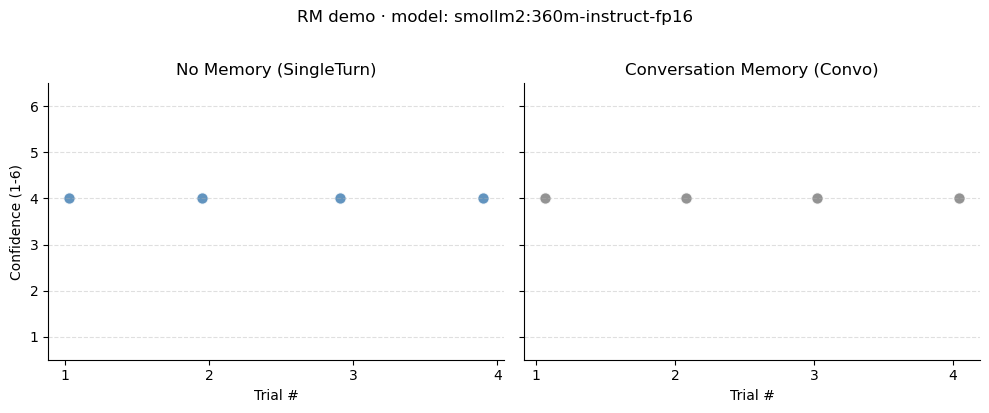

figure → /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/csv/rm_demo_figure.png


In [8]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ResponseRmStEI parser returns a 'Confidence' (1-6) field — extract it for plotting
_CONF_RE = re.compile(r"Confidence['\"]?\s*[:=]\s*(\d+)")

def load_confidence(csv_path):
    df = pd.read_csv(csv_path)
    df['Confidence'] = df['pred_resp_raw'].apply(
        lambda s: int(_CONF_RE.search(str(s)).group(1)) if _CONF_RE.search(str(s)) else None
    )
    return (df['trial_idx'] + 1).values.astype(float), df['Confidence'].values.astype(float)

x_st, y_st = load_confidence(OUT / 'rm_singleturn.csv')
x_cv, y_cv = load_confidence(OUT / 'rm_convo.csv')

rng = np.random.default_rng(0)
def jitter(x, s=0.10): return x + rng.uniform(-s, s, size=len(x))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
ax1.scatter(jitter(x_st), y_st, color='steelblue', s=70, alpha=0.85, edgecolors='white')
ax1.set_title('No Memory (SingleTurn)'); ax1.set_xlabel('Trial #'); ax1.set_ylabel('Confidence (1-6)')
ax2.scatter(jitter(x_cv), y_cv, color='gray', s=70, alpha=0.85, edgecolors='white')
ax2.set_title('Conversation Memory (Convo)'); ax2.set_xlabel('Trial #')
for ax in (ax1, ax2):
    ax.set_xticks(range(1, int(max(x_st.max(), x_cv.max())) + 1))
    ax.set_ylim(0.5, 6.5); ax.set_yticks(range(1, 7))
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(f'RM demo · model: {MODEL_NAME}', y=1.02)
plt.tight_layout()
fig.savefig(OUT / 'rm_demo_figure.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'figure → {OUT / "rm_demo_figure.png"}')


## Verify install by running the README Quick Start test directly

This calls the test function from `tests/test_readme_quickstart.py` without
invoking pytest — so unrelated tests (like `test_cli.py`) are never touched.


In [9]:
import sys, tempfile, urllib.request, urllib.error
from pathlib import Path

# Make the package's tests/ importable (it has __init__.py, so it works as a module)
PKG_ROOT = Path.cwd().parent
if str(PKG_ROOT) not in sys.path:
    sys.path.insert(0, str(PKG_ROOT))

from tests.test_readme_quickstart import (
    test_readme_quickstart_smoke,
    test_readme_quickstart_live_ollama,
)

# 1. Smoke test: validates ExpCard, default task, parser registry — no API calls
with tempfile.TemporaryDirectory() as tmp:
    test_readme_quickstart_smoke(Path(tmp))
print("PASS — README Quick Start smoke test")

# 2. Live Ollama test: skipped if Ollama isn't reachable on localhost
def _ollama_up(timeout=2.0):
    try:
        with urllib.request.urlopen("http://localhost:11434/api/tags", timeout=timeout) as r:
            return r.status == 200
    except (urllib.error.URLError, TimeoutError, ConnectionError):
        return False

if _ollama_up():
    try:
        with tempfile.TemporaryDirectory() as tmp:
            test_readme_quickstart_live_ollama(Path(tmp))
        print("PASS — README Quick Start live Ollama test")
    except Exception as e:
        print(f"SKIPPED live test: {type(e).__name__}: {str(e)[:140]}")
else:
    print("SKIPPED live test: Ollama not reachable on localhost:11434")


----<PROJECT AND DATA ROOT DIRECTORY>----
	Project root dir: /var/folders/2f/1mng0xs503787mwn287f9_d00000gn/T/tmp5snftlkv
	Simulation data root dir: /var/folders/2f/1mng0xs503787mwn287f9_d00000gn/T/tmp5snftlkv/readme_quickstart_test/vviq16/ollama_smollm2:360m-instruct-fp16_SingleTurn
----<>----
--<api key>-- warning: OLLAMA_API_KEY not set; proceeding without explicit api_key for family 'ollama'
--<chat model>-- model='smollm2:360m-instruct-fp16'
PASS — README Quick Start smoke test
----<PROJECT AND DATA ROOT DIRECTORY>----
	Project root dir: /var/folders/2f/1mng0xs503787mwn287f9_d00000gn/T/tmpqu25mhpm
	Simulation data root dir: /var/folders/2f/1mng0xs503787mwn287f9_d00000gn/T/tmpqu25mhpm/readme_quickstart_test/vviq16/ollama_smollm2:360m-instruct-fp16_SingleTurn
----<>----
--<api key>-- warning: OLLAMA_API_KEY not set; proceeding without explicit api_key for family 'ollama'
--<chat model>-- model='smollm2:360m-instruct-fp16' temperature=0.0


2026-05-07 15:40:08.656 | CRITICAL | psychscanner.session_tunnel.session_tunnel:create_tunnel:152 - BEGIN


TOTAL RUNS: 1	RESUME IDX: None
----<>---- task running


16it [00:15,  1.03it/s]
2026-05-07 15:40:24.231 | INFO     | psychscanner.session_tunnel.session_tunnel:scan_checkpoint:184 - scan-checkpoint


----<scanned runs>---- i = 0


2026-05-07 15:40:24.235 | CRITICAL | psychscanner.session_tunnel.session_tunnel:end_checkpoint:163 - END


Saved 16 rows → /var/folders/2f/1mng0xs503787mwn287f9_d00000gn/T/tmpqu25mhpm/readme_quickstart_test_vviq16_smollm2-360m-instruct-fp16_SingleTurn_20260507_154024.csv
PASS — README Quick Start live Ollama test


## VVIQ-16 mini study (lifted from the unit test)

This block runs the same VVIQ-16 task validated by
`tests/test_readme_quickstart.py::test_readme_quickstart_live_ollama`,
then adds a **Convo** condition for comparison and reproduces the
`09_vviq16_study.ipynb` plot at small scale.


In [10]:
# Mirror of test_readme_quickstart_live_ollama (n=2 instead of 1)
from psychscanner import ExpCardInit, ExpCard, ScannerModel, to_csv
from psychscanner.parsers import DefaultLiteralVivid15

VVIQ_DIR = RUN_DIR / "vviq16"
VVIQ_DIR.mkdir(parents=True, exist_ok=True)
NSIM = 2  # small for a quick local run; bump up for real studies

def vviq_card(memory: str):
    return ExpCardInit(
        model       = MODEL_NAME,
        family      = MODEL_FAMILY,
        parameters  = {"temperature": 0},
        projectname = "vviq16_quickstart",
        proj_dir    = VVIQ_DIR,
        cogtype     = "no",
        nsim        = NSIM,
        memory      = memory,
        parser      = DefaultLiteralVivid15,
    )

scanner_st = ScannerModel(expcard=ExpCard(vviq_card("SingleTurn")))
results_st = scanner_st.run()
print(f"SingleTurn: {len(results_st)} simulations × {len(results_st[0])} trials")


----<PROJECT AND DATA ROOT DIRECTORY>----
	Project root dir: /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/vviq16
	Simulation data root dir: /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/vviq16/vviq16_quickstart/vviq16/ollama_smollm2:360m-instruct-fp16_SingleTurn
----<>----
--<api key>-- warning: OLLAMA_API_KEY not set; proceeding without explicit api_key for family 'ollama'
--<chat model>-- model='smollm2:360m-instruct-fp16' temperature=0.0


2026-05-07 15:40:24.350 | CRITICAL | psychscanner.session_tunnel.session_tunnel:create_tunnel:152 - BEGIN


TOTAL RUNS: 2	RESUME IDX: None
----<>---- task running


16it [00:15,  1.06it/s]
2026-05-07 15:40:39.483 | INFO     | psychscanner.session_tunnel.session_tunnel:scan_checkpoint:184 - scan-checkpoint


----<scanned runs>---- i = 0
----<>---- task running


16it [00:13,  1.15it/s]
2026-05-07 15:40:53.410 | INFO     | psychscanner.session_tunnel.session_tunnel:scan_checkpoint:184 - scan-checkpoint


----<scanned runs>---- i = 1


2026-05-07 15:40:53.412 | CRITICAL | psychscanner.session_tunnel.session_tunnel:end_checkpoint:163 - END


SingleTurn: 2 simulations × 16 trials


In [11]:
scanner_cv = ScannerModel(expcard=ExpCard(vviq_card("Convo")))
results_cv = scanner_cv.run()
print(f"Convo:      {len(results_cv)} simulations × {len(results_cv[0])} trials")


----<PROJECT AND DATA ROOT DIRECTORY>----
	Project root dir: /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/vviq16
	Simulation data root dir: /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/vviq16/vviq16_quickstart/vviq16/ollama_smollm2:360m-instruct-fp16_Convo
----<>----
--<api key>-- warning: OLLAMA_API_KEY not set; proceeding without explicit api_key for family 'ollama'
--<chat model>-- model='smollm2:360m-instruct-fp16' temperature=0.0


2026-05-07 15:40:53.637 | CRITICAL | psychscanner.session_tunnel.session_tunnel:create_tunnel:152 - BEGIN


TOTAL RUNS: 2	RESUME IDX: None
----<>---- task running


16it [00:28,  1.75s/it]
2026-05-07 15:41:21.681 | INFO     | psychscanner.session_tunnel.session_tunnel:scan_checkpoint:184 - scan-checkpoint


----<scanned runs>---- i = 0
----<>---- task running


16it [00:25,  1.57s/it]
2026-05-07 15:41:46.859 | INFO     | psychscanner.session_tunnel.session_tunnel:scan_checkpoint:184 - scan-checkpoint


----<scanned runs>---- i = 1


2026-05-07 15:41:46.863 | CRITICAL | psychscanner.session_tunnel.session_tunnel:end_checkpoint:163 - END


Convo:      2 simulations × 16 trials


In [12]:
# Export per-condition + combined CSVs
df_st = to_csv(scanner_st, path=VVIQ_DIR / "vviq16_singleturn.csv")
df_cv = to_csv(scanner_cv, path=VVIQ_DIR / "vviq16_convo.csv")
df_all = to_csv([scanner_st, scanner_cv],
                path=VVIQ_DIR / "vviq16_combined.csv",
                combined=True)
print(f"SingleTurn rows: {df_st.shape}")
print(f"Convo      rows: {df_cv.shape}")
print(f"Combined   rows: {df_all.shape}")
df_all.select(["memory", "trcode", "trial_idx", "resp_Vividness"]).head(6)


Saved 32 rows → /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/vviq16/vviq16_singleturn.csv
Saved 32 rows → /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/vviq16/vviq16_convo.csv
Saved 64 rows from 2 source(s) → /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/vviq16/vviq16_combined.csv
SingleTurn rows: (32, 20)
Convo      rows: (32, 20)
Combined   rows: (64, 20)


memory,trcode,trial_idx,resp_Vividness
str,str,i64,i64
"""SingleTurn""","""S1_1""",0,4
"""SingleTurn""","""S1_2""",1,4
"""SingleTurn""","""S1_3""",2,4
"""SingleTurn""","""S1_4""",3,4
"""SingleTurn""","""S2_1""",4,4
"""SingleTurn""","""S2_2""",5,4


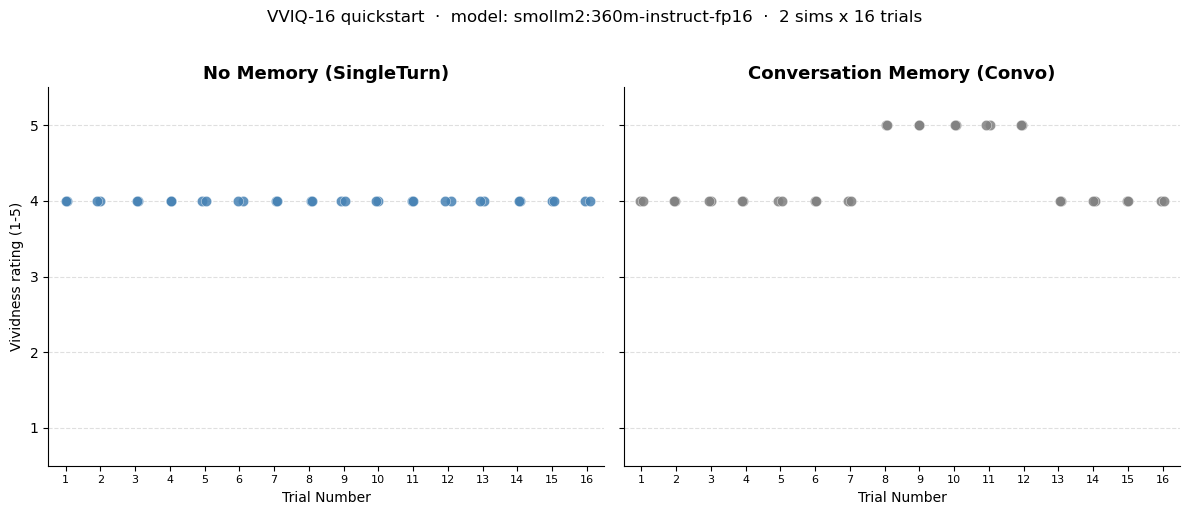

figure -> /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/vviq16/vviq16_figure.png
mean Vividness  SingleTurn=4.00  Convo=4.31


In [13]:
# Reproduce the 09_vviq16_study.ipynb scatter (small-n version)
import re, numpy as np, pandas as pd
import matplotlib.pyplot as plt

_VIV_RE = re.compile(r"Vividness[^0-9]*(\d+)")

def load_vividness(csv_path):
    df = pd.read_csv(csv_path)
    df["Vividness"] = df["pred_resp_raw"].apply(
        lambda s: int(_VIV_RE.search(str(s)).group(1)) if _VIV_RE.search(str(s)) else None
    )
    return (df["trial_idx"] + 1).values.astype(float), df["Vividness"].values.astype(float)

x_st, y_st = load_vividness(VVIQ_DIR / "vviq16_singleturn.csv")
x_cv, y_cv = load_vividness(VVIQ_DIR / "vviq16_convo.csv")

rng = np.random.default_rng(42)
def jitter(x, s=0.10): return x + rng.uniform(-s, s, size=len(x))

fig, (ax_st, ax_cv) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
ax_st.scatter(jitter(x_st), y_st, color="steelblue", s=55, alpha=0.85,
              linewidths=0.3, edgecolors="white", zorder=3)
ax_st.set_title("No Memory (SingleTurn)", fontsize=13, fontweight="bold")
ax_st.set_xlabel("Trial Number"); ax_st.set_ylabel("Vividness rating (1-5)")

ax_cv.scatter(jitter(x_cv), y_cv, color="gray", s=55, alpha=0.85,
              linewidths=0.3, edgecolors="white", zorder=3)
ax_cv.set_title("Conversation Memory (Convo)", fontsize=13, fontweight="bold")
ax_cv.set_xlabel("Trial Number")

for ax in (ax_st, ax_cv):
    ax.set_xlim(0.5, 16.5); ax.set_xticks(range(1, 17))
    ax.set_xticklabels(range(1, 17), fontsize=8)
    ax.set_ylim(0.5, 5.5); ax.set_yticks([1, 2, 3, 4, 5])
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(f"VVIQ-16 quickstart  ·  model: {MODEL_NAME}  ·  {NSIM} sims x 16 trials",
             fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(VVIQ_DIR / "vviq16_figure.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"figure -> {VVIQ_DIR / 'vviq16_figure.png'}")
m_st = float(np.nanmean(y_st)) if y_st.size else float("nan")
m_cv = float(np.nanmean(y_cv)) if y_cv.size else float("nan")
print(f"mean Vividness  SingleTurn={m_st:.2f}  Convo={m_cv:.2f}")
